In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import kruskal
from scipy.stats import levene
from scipy.stats import shapiro

In [5]:
df_aerofit = pd.read_csv('../../assets/aerofit_data.csv')
df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [7]:
df_aerofit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [9]:
df_aerofit['Product'].value_counts()

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

<Axes: xlabel='Product', ylabel='Income'>

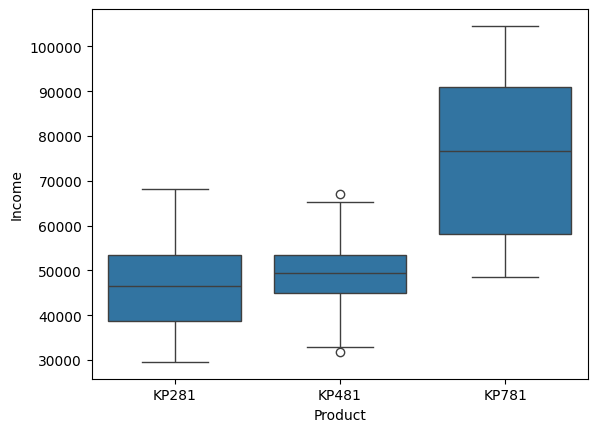

In [59]:
sns.boxplot(x='Product', y='Income', data=df_aerofit)

<Axes: xlabel='Income', ylabel='Count'>

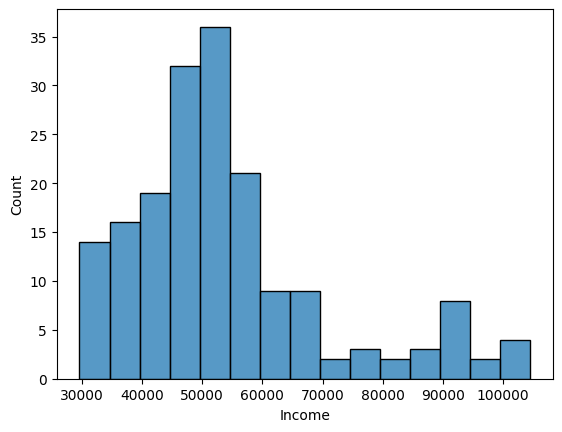

In [63]:
sns.histplot(df_aerofit['Income'])

In [13]:
np.random.seed(42)
df_aerofit['random_group'] = np.random.choice(["g1","g2","g3"], size=len(df_aerofit))
df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,random_group
0,KP281,18,Male,14,Single,3,4,29562,112,g3
1,KP281,19,Male,15,Single,2,3,31836,75,g1
2,KP281,19,Female,14,Partnered,4,3,30699,66,g3
3,KP281,19,Male,12,Single,3,3,32973,85,g3
4,KP281,20,Male,13,Partnered,4,2,35247,47,g1


<Axes: xlabel='random_group', ylabel='Income'>

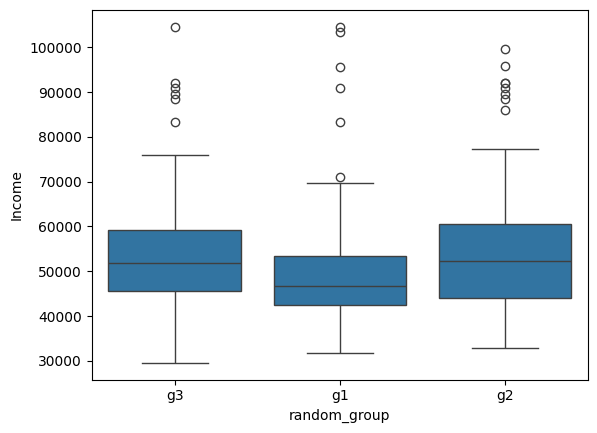

In [16]:
sns.boxplot(x='random_group', y='Income', data=df_aerofit)

In [20]:
income_g1 = df_aerofit[df_aerofit['random_group'] == 'g1']['Income']
income_g2 = df_aerofit[df_aerofit['random_group'] == 'g2']['Income']
income_g3 = df_aerofit[df_aerofit['random_group'] ==    'g3']['Income']
g1_mean = income_g1.mean()
g2_mean = income_g2.mean()
g3_mean = income_g3.mean()
print(f"Group 1 Mean: {g1_mean}")
print(f"Group 2 Mean: {g2_mean}")
print(f"Group 3 Mean: {g3_mean}")

Group 1 Mean: 51840.44827586207
Group 2 Mean: 55812.69642857143
Group 3 Mean: 53594.954545454544


In [28]:
H0 = "All groups have the same mean"
HA = "One or more groups have different mean"

f_stats, p_value = f_oneway(income_g1, income_g2, income_g3)
print(f"F-statistic: {f_stats}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the null hypothesis means: '{HA}'")
else:
    print(f"Fail to reject the null hypothesis means: '{H0}'")

F-statistic: 0.8263259710788367
P-value: 0.4393354180119148
Fail to reject the null hypothesis means: 'All groups have the same mean'


checking whether groups have similar variance using ### Levene Test

In [47]:
H0 = 'All groups have similar variances'
HA = 'At least one group has a different variance'

l_stat, p_value = levene(income_g1, income_g2, income_g3)
print(f"Levene's statistic: {l_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the null hypothesis means: '{HA}'")  
else:
    print(f"Fail to reject the null hypothesis means: '{H0}'")

Levene's statistic: 0.4159119272736633
P-value: 0.6603814377662338
Fail to reject the null hypothesis means: 'All groups have similar variances'


Check whether data follows Normal distribution using ### Shapiro-Wilk test

In [58]:
H0 = 'Data is normally distributed'
HA = 'Data is not normally distributed'

s_stat, p_value = shapiro(income_g1)
print(f"Shapiro-Wilk statistic: {s_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the null hypothesis means: '{HA}'")  
else:
    print(f"Fail to reject the null hypothesis means: '{H0}'")

Shapiro-Wilk statistic: 0.8153278344699345
P-value: 4.7120459130465024e-07
Reject the null hypothesis means: 'Data is not normally distributed'


<Axes: xlabel='Product', ylabel='Income'>

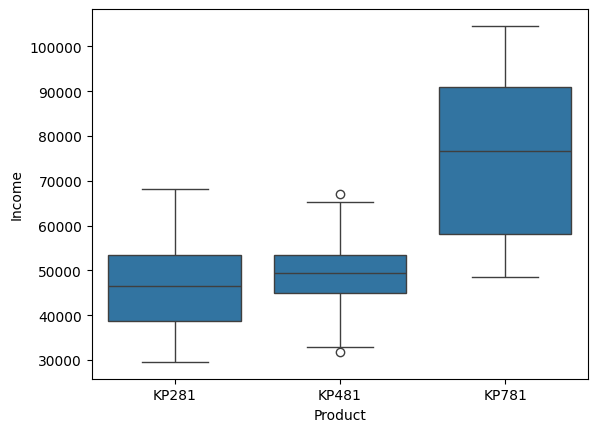

In [31]:
sns.boxplot(x='Product', y='Income', data=df_aerofit)

In [33]:
income_kp281 = df_aerofit[df_aerofit['Product'] == 'KP281']['Income']
income_kp481 = df_aerofit[df_aerofit['Product'] == 'KP481']['Income']   
income_kp781 = df_aerofit[df_aerofit['Product'] == 'KP781']['Income']

kp281_mean = income_kp281.mean()
kp481_mean = income_kp481.mean()
kp781_mean = income_kp781.mean()
print(f"KP281 Mean: {kp281_mean}")
print(f"KP481 Mean: {kp481_mean}")
print(f"KP781 Mean: {kp781_mean}")

KP281 Mean: 46418.025
KP481 Mean: 48973.65
KP781 Mean: 75441.575


In [34]:
f_stat, p_value = f_oneway(income_kp281, income_kp481, income_kp781)
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

if p_value < alpha:
    print(f"Reject the null hypothesis means: '{HA}'")
else:
    print(f"Fail to reject the null hypothesis means: '{H0}'")

F-statistic: 89.25903546601671
P-value: 1.564499131634248e-27
Reject the null hypothesis means: 'One or more groups have different mean'


Approaching the Problem with 2-Sample T-Test

Let's test the relation between Income and Product to find out which group have a different mean.

We can use T-test to check for a relation between these features.

However, since T-test only caters to categorical features with 2 variables, we would need to perform independent T-tests multiple times, by pairing the income data as:

Income of customers who bought KP281 vs. KP481

Income of customers who bought KP781 vs. KP481

Income of customers who bought KP281 vs. KP781

This approach is also known as Pairwise T-test, as we looking testing if there is a significant difference among each possible pair, one by one.

In [37]:
t_stat, p_value = ttest_ind(income_kp781, income_kp481)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < alpha:
    print(f"Reject the null hypothesis means: '{HA}'")
else:
    print(f"Fail to reject the null hypothesis means: '{H0}'")

T-statistic: 9.628009470104809
P-value: 7.770191623361236e-16
Reject the null hypothesis means: 'One or more groups have different mean'


In [39]:
t_stat, p_value = ttest_ind(income_kp781, income_kp281)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < alpha:
    print(f"Reject HO means: '{HA}'")
else:
    print(f"Fail to reject HO means: '{H0}'")

T-statistic: 11.551787854717519
P-value: 4.116508528877672e-21
Reject HO means: 'One or more groups have different mean'


Income groups KP781 vs. KP481 & KP281 vs. KP781 have different means.

### Assumptions of One Way ANOVA
To implement the One-way ANOVA test, we need to make sure that they are satisfying certain conditions:

1. Data should be normally distributed (i.e, Gaussian)
2. Data should be independent across each record
3. Equal variance in different groups

In real world, we might not always find Gaussian data.

> **How will we conduct our hypothesis test, in case our data is not Gaussian?**

##  <font color='red'>Kruskal-Wallis test</font>

The Kruskal-Wallis test is a statistical test used to compare the medians of two or more independent groups.

It is an alternative to the one-way ANOVA, making it useful when data is not normally distributed.

Null Hypothesis (H0):

> The populations of all groups have the same median.
    > In other words, there is no statistically significant difference in the medians of the groups being compared.
Alternative Hypothesis (H1):

At least one of the populations has a different median.
There is a statistically significant difference in the medians of at least two groups.

Advantages of Kruskal-Wallis Test:

> No assumption of normality: It doesn't require the data to be normally distributed.
> Robust to outliers: Outliers don't significantly affect the results.

Limitations of Kruskal-Wallis Test:

Doesn't provide information about which groups differ: It only tells you if there is a difference, not which groups specifically differ.
Less powerful than ANOVA when assumptions are met: If the data is normally distributed and has no outliers, ANOVA is more powerful.

In [43]:
k_stat, p_value = kruskal(income_g1, income_g2, income_g3)
print(f"Kruskal-Wallis statistic: {k_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the HO means: '{HA}'")
else:
    print(f"Fail to reject the HO means: '{H0}'")

Kruskal-Wallis statistic: 2.720864198623469
P-value: 0.2565498979655774
Fail to reject the HO means: 'All groups have the same mean'


Let's apply ANOVA to see if there is a relation between Income and Product features

In [44]:
k_stat, p_value = kruskal(income_kp281, income_kp481, income_kp781)
print(f"Kruskal-Wallis statistic: {k_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the HO means: '{HA}'")
else:
    print(f"Fail to reject the HO means: '{H0}'")

Kruskal-Wallis statistic: 61.43670384567185
P-value: 4.562357014275808e-14
Reject the HO means: 'One or more groups have different mean'
